In [135]:
## core packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [136]:
## Image handling
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [137]:
## Model
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

In [138]:
splitfolders.ratio(
    "cell",        # input folder
    output="dataset",  # output folder
    seed=42,
    ratio=(0.8, 0.1, 0.1)  # train, val, test
)

In [139]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.1,
    brightness_range = (0.8,1.2),
    fill_mode = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale = 1./255
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [140]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
   
)

val_generator = val_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
    
)

test_generator = test_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
  
)

Found 421 images belonging to 2 classes.
Found 421 images belonging to 2 classes.
Found 421 images belonging to 2 classes.


In [141]:
train_generator.class_indices

{'Negative': 0, 'Positive': 1}

In [142]:
## check batches
images, labels = next(train_generator)
print(images.shape, labels.shape)

(32, 224, 224, 3) (32,)


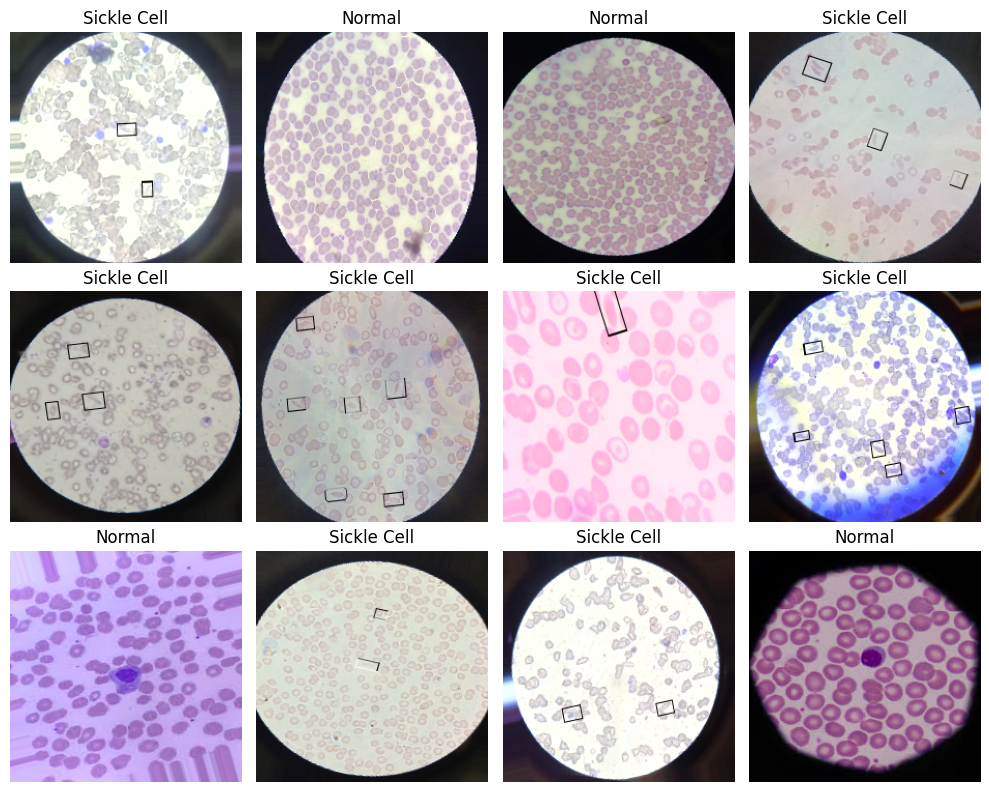

In [143]:
plt.figure(figsize=(10,8))
for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i+1)
    
    # images are usually normalized (0-1), scale back for display
    plt.imshow(images[i])
    
    # For binary classification, labels might be 0 or 1
    label_text = "Sickle Cell" if labels[i] > 0.5 else "Normal"
    plt.title(label_text)
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [144]:

images[0]

array([[[0.21176472, 0.23529413, 0.20392159],
        [0.21176472, 0.23529413, 0.20392159],
        [0.21176472, 0.23529413, 0.20392159],
        ...,
        [0.13333334, 0.14117648, 0.1254902 ],
        [0.13333334, 0.14117648, 0.1254902 ],
        [0.13333334, 0.14117648, 0.1254902 ]],

       [[0.21960786, 0.24313727, 0.21568629],
        [0.21960786, 0.24313727, 0.21568629],
        [0.21960786, 0.24313727, 0.21568629],
        ...,
        [0.13333334, 0.13333334, 0.12156864],
        [0.13333334, 0.13333334, 0.12156864],
        [0.13333334, 0.13333334, 0.12156864]],

       [[0.21568629, 0.2392157 , 0.21176472],
        [0.21568629, 0.2392157 , 0.21176472],
        [0.21568629, 0.2392157 , 0.21176472],
        ...,
        [0.14509805, 0.14509805, 0.13725491],
        [0.14509805, 0.14509805, 0.13725491],
        [0.14901961, 0.14901961, 0.14117648]],

       ...,

       [[0.07058824, 0.08627451, 0.10980393],
        [0.07058824, 0.08627451, 0.10980393],
        [0.07058824, 0

In [145]:

base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224,224,3))


In [146]:
for layer in base_model.layers:
    layer.trainable = False

In [147]:


inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [148]:
## compile
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d_5   (None, 1024)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_10 (Dense)            (None, 128)               131200    
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 7,168,833
Trainable params: 131,329
Non-trainable params: 7,037,504
___________________________________________

In [149]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=20
)

Epoch 1/20
14/14 [==============================] - 57s 4s/step - loss: 0.3066 - accuracy: 0.8575 - val_loss: 0.1031 - val_accuracy: 0.9739
Epoch 2/20
14/14 [==============================] - 57s 4s/step - loss: 0.0804 - accuracy: 0.9762 - val_loss: 0.0911 - val_accuracy: 0.9691
Epoch 3/20
14/14 [==============================] - 75s 5s/step - loss: 0.0649 - accuracy: 0.9810 - val_loss: 0.0647 - val_accuracy: 0.9834
Epoch 4/20
14/14 [==============================] - 52s 4s/step - loss: 0.0551 - accuracy: 0.9810 - val_loss: 0.0503 - val_accuracy: 0.9834
Epoch 5/20
14/14 [==============================] - 63s 5s/step - loss: 0.0381 - accuracy: 0.9905 - val_loss: 0.0448 - val_accuracy: 0.9834
Epoch 6/20
14/14 [==============================] - 68s 5s/step - loss: 0.0415 - accuracy: 0.9881 - val_loss: 0.0502 - val_accuracy: 0.9810
Epoch 7/20
14/14 [==============================] - 51s 4s/step - loss: 0.0350 - accuracy: 0.9881 - val_loss: 0.0354 - val_accuracy: 0.9905
Epoch 8/20
14/14 [==

In [150]:
model.evaluate(test_generator)

14/14 [==============================] - 42s 3s/step - loss: 0.0377 - accuracy: 0.9929


[0.037721868604421616, 0.9928740859031677]

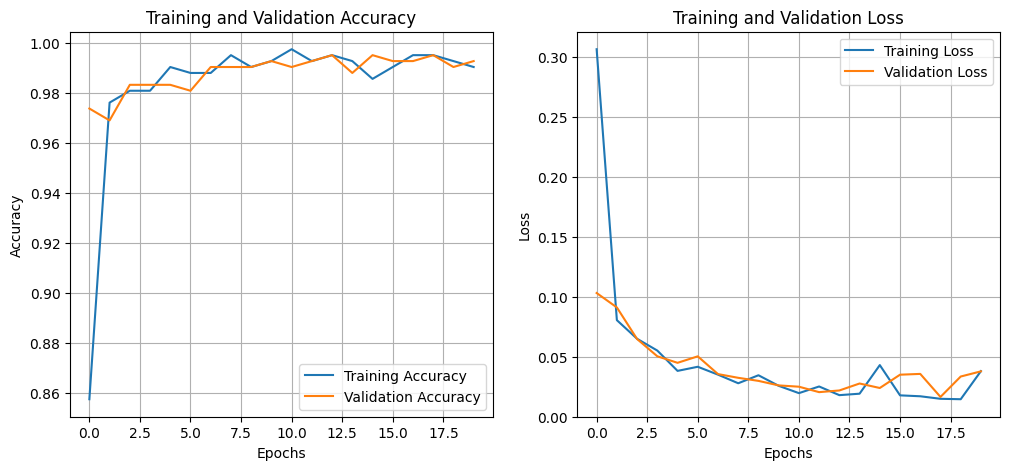

In [151]:
plt.figure(figsize=(12,5))

## plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

## plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

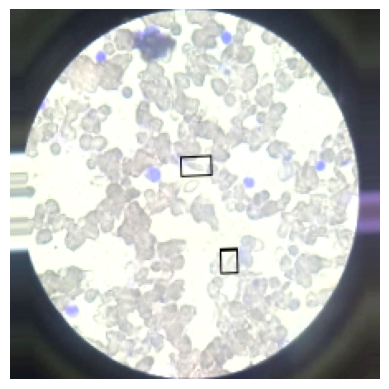

Actual label: Sickle Cell
1/1 [==============================] - 3s 3s/step
Predicted label: Sickle Cell
Confidence: 0.99999946


In [152]:
first_image = images[0]  # shape: (224,224,3)
first_label = labels[0]  # 0 or 1 for binary

# Show the image
plt.imshow(first_image)
plt.axis("off")
plt.show()

# Print the actual label
label_text = "Sickle Cell" if first_label > 0.5 else "Normal"
print("Actual label:", label_text)

# Make prediction
prediction = model.predict(np.expand_dims(first_image, axis=0))  # add batch dimension
pred_label_text = "Sickle Cell" if prediction[0][0] > 0.5 else "Normal"
print("Predicted label:", pred_label_text)
print("Confidence:", prediction[0][0])

In [153]:
# Prediction function for a single image
def predict(model, img):
    # img is already a numpy array from ImageDataGenerator
    img_array = np.expand_dims(img, axis=0)  # create a batch
    prediction = model.predict(img_array)
    
    # For binary classification (sigmoid output)
    if prediction[0][0] > 0.5:
        predicted_class = "Sickle Cell"
    else:
        predicted_class = "Normal"
    
    confidence = round(100 * max(prediction[0][0], 1 - prediction[0][0]), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 176ms/step


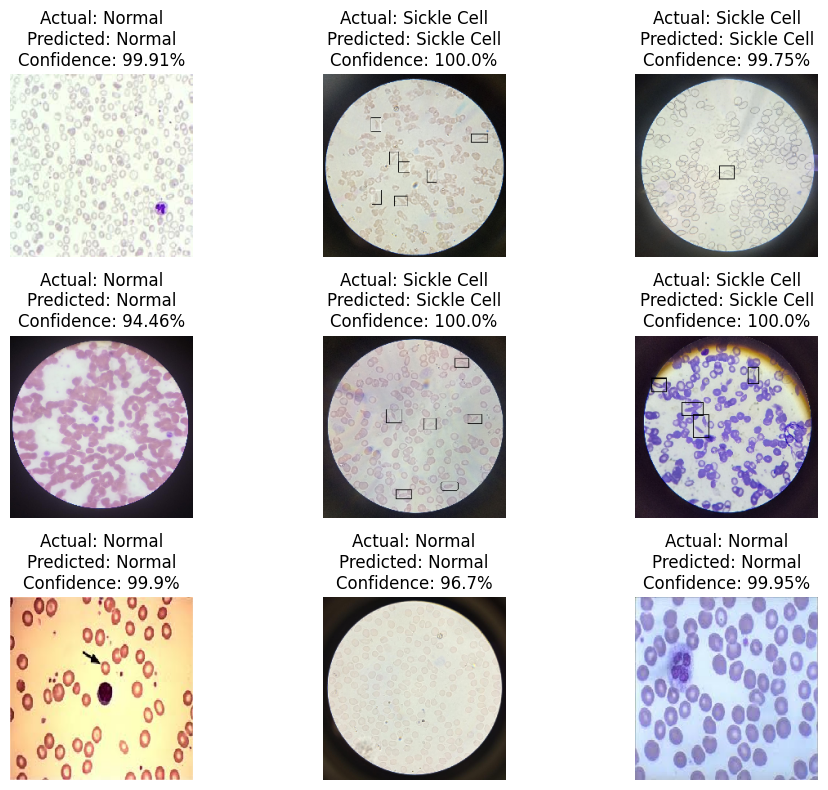

In [154]:
# Visualize predictions
plt.figure(figsize=(10,8))

# Get one batch from your test generator
images, labels = next(test_generator)  # test_generator = ImageDataGenerator.flow(...)

for i in range(9):  # show 9 images
    ax = plt.subplot(3,3, i+1)
    plt.imshow(images[i])
    
    predicted_class, confidence = predict(model, images[i])
    
    # Actual class
    actual_class = "Sickle Cell" if labels[i] > 0.5 else "Normal"
    
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [156]:

# Save model for TF Serving
model.save("models/sickle-cell/1") 

INFO:tensorflow:Assets written to: models/sickle-cell/1\assets


INFO:tensorflow:Assets written to: models/sickle-cell/1\assets
